# Early Nyquist Results for Stability

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [27]:
colors = bm.get_colors()

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import LogLocator, ScalarFormatter
import sympy as sp

import control as ct
import control.matlab as cmat

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

## Examples from Lecture 17

<IPython.core.display.Math object>

None

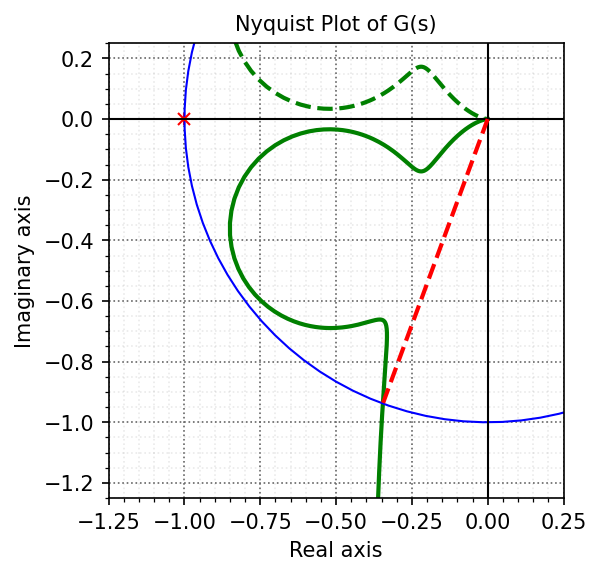

Phase Margin = 69.77

Found break-in/out at K =  0.632
At possible locations s = -0.513


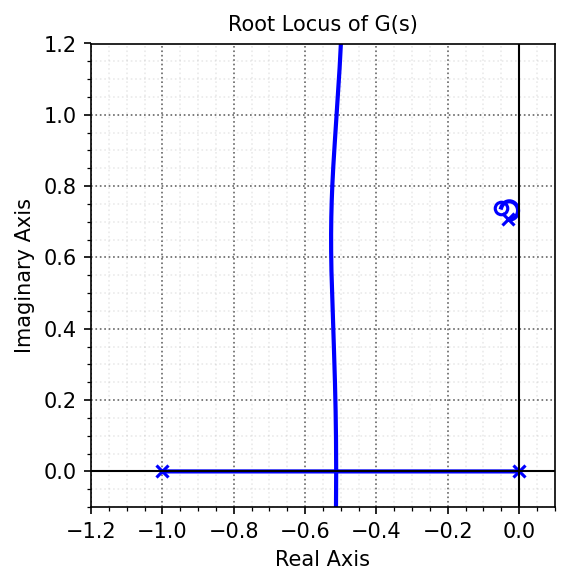

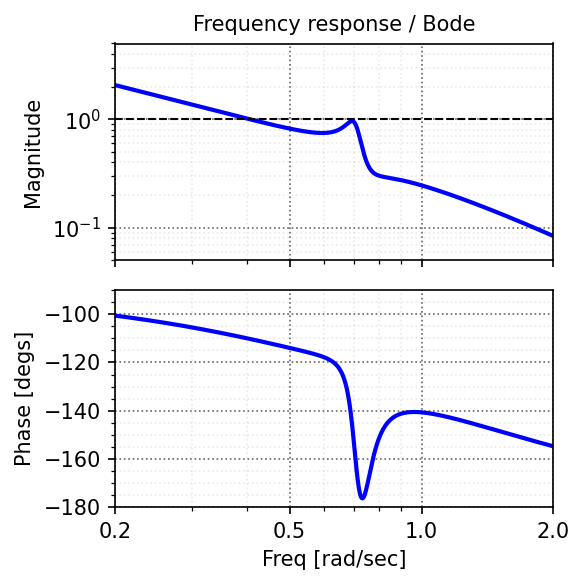

In [28]:
# L17 PM/GM Examples
w = np.hstack(([0.0], np.logspace(-3,3,5000)))

an = np.linspace(0, 2 * np.pi, 100) # unit circle

#L(s) =  \frac{0.38( s^2 + 0.1 s + 0.55)}{s(s+1)(s^2+0.06s+0.5)}
G = 0.38*ct.tf([1],[1, 1, 0])*ct.tf([1,.1,.55],[1,.06,.5]) 
display(cm.show_tf_latex(G,'G(s)'))

[Gm,Gp,Gw] = ct.frequency_response(G,omega=w)

fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
plt.sca(ax);kwargs = {'color':'g'}
#ct.nyquist_plot(G,w,indent_direction='right',indent_points=100,**kwargs)
cm.nyquist(G,w,indent_direction='right',indent_points=100,**kwargs)
#lines = ax.get_lines()
#[lines[x].set_linestyle('-') for x in range(int(len(lines)/2.))]

plt.plot(np.cos(an), np.sin(an),'b-',lw=1)
plt.plot(-1,0,'rx',ms=6)
ax.set_aspect('equal')
plt.xlim([-1.25,.25])
plt.ylim([-1.25,.25])
plt.title('Nyquist Plot of G(s)')
#fig.suptitle("")  # clear it directly
bm.nicegrid(ax)

gm, pm, wcg, wcp =  ct.margin(G)
#print([gm,wcg,pm,wcp])
plt.plot([0,-np.cos(pm/cm.r2d)],[0,-np.sin(pm/cm.r2d)],'r--')
plt.savefig("./figs/L19_GM_PM_1.pdf", dpi=600)
plt.show()

print("Phase Margin = {:3.2f}".format(pm))

fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
rl = ct.rlocus(G, gains=cm.Root_Locus_gains(G), color='b', ax=ax)
bm.nicegrid(ax)
ax.set_aspect('equal')
ax.set_xlim([-1.2,.1])
ax.set_ylim([-0.1,1.2])
ax.set_title('Root Locus of G(s)')
ax.set_xlabel('Real Axis')
ax.set_ylabel('Imaginary Axis') 
plt.savefig("./figs/L19_GM_PM_1a.pdf", dpi=600)

fig, ax = plt.subplots(2,1,figsize=(4, 4),dpi=150, sharex = True)
ax[0].loglog(Gw,Gm,'b')
ax[1].semilogx(Gw,Gp*cm.r2d,'b')
ax[0].set_xlim([.2,2])
ax[0].set_ylim([.05,5])
ax[1].set_ylim([-180,-90])
ax[1].set_xlabel('Freq [rad/sec]')
ax[1].set_ylabel('Phase [degs]')
ax[0].set_ylabel('Magnitude')
ax[0].grid(True, which="both", ls="-",color='0.65')
ax[1].grid(True, which="both", ls="-",color='0.65')
ax[0].set_title("Frequency response / Bode")
#import matplotlib.ticker as mticker
#ax[1].xaxis.set_minor_formatter(mticker.ScalarFormatter())
bm.nicegrid(ax)

from matplotlib.ticker import LogLocator, ScalarFormatter
ax[0].set_xscale('log')
ax[0].xaxis.set_major_locator(LogLocator(base=10, subs=(1.0, 2.0, 5.0)))
ax[0].xaxis.set_major_formatter(ScalarFormatter())
ax[0].xaxis.set_minor_formatter(plt.NullFormatter())
plt.savefig("./figs/L19_GM_PM_1b.pdf", dpi=600)

#fig_width, fig_height = plt.gcf().get_size_inches()
#print(fig_width, fig_height)

## L17 PM/GM Examples - Robustness Question

<IPython.core.display.Math object>

None

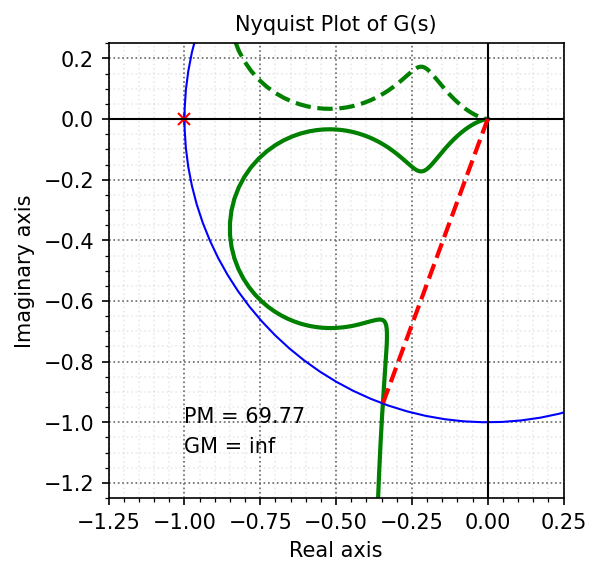

In [29]:
w = np.hstack(([0.0], np.logspace(-3,3,5000)))
an = np.linspace(0, 2 * np.pi, 100) # unit circle

#L(s) =  \frac{0.38( s^2 + 0.1 s + 0.55)}{s(s+1)(s^2+0.06s+0.5)}
G = 0.38*ct.tf([1],[1, 1, 0])*ct.tf([1,.1,.55],[1,.06,.5]) 
display(cm.show_tf_latex(G,'G(s)'))

[Gm,Gp,Gw] = ct.frequency_response(G,omega=w)

fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
plt.sca(ax);kwargs = {'color':'g'}
cm.nyquist(G,w,indent_direction='right',indent_points=100,**kwargs)

plt.plot(np.cos(an), np.sin(an),'b-',lw=1)
plt.plot(-1,0,'rx',ms=6)
ax.set_aspect('equal')
plt.xlim([-1.25,.25])
plt.ylim([-1.25,.25])
bm.nicegrid(ax)
plt.title('Nyquist Plot of G(s)')

gm, pm, wcg, wcp =  ct.margin(G)
plt.plot([0,-np.cos(pm/cm.r2d)],[0,-np.sin(pm/cm.r2d)],'r--')

Gf = G(complex(0,1)*w)
S = 1/(1+Gf)
dist_from_cp = 1/np.max(np.abs(S))
plt.plot(-1+dist_from_cp*np.cos(an), dist_from_cp*np.sin(an),'r--',lw=1)

ax.text(-1,-1,"PM = {:3.2f}".format(pm),fontsize=10)
ax.text(-1,-1.1,"GM = {:3.2f}".format(gm),fontsize=10)
plt.savefig("./figs/L19_Rob_1.pdf", dpi=600)
plt.show()


### $$L(s) =  \frac{0.3( s^2 - 0.075 s + 0.95)}{s(s+1)(s^2+0.025s+0.9)}$$

<IPython.core.display.Math object>

None

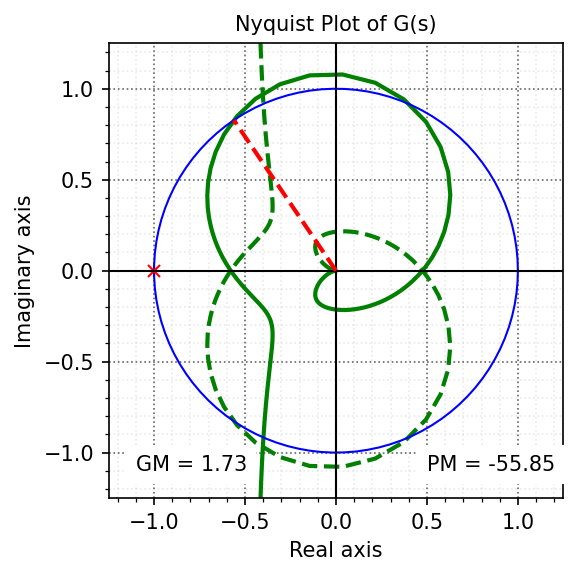

Phase Margin = -55.85

Found break-in/out at K =  0.605
At possible locations s = -0.499


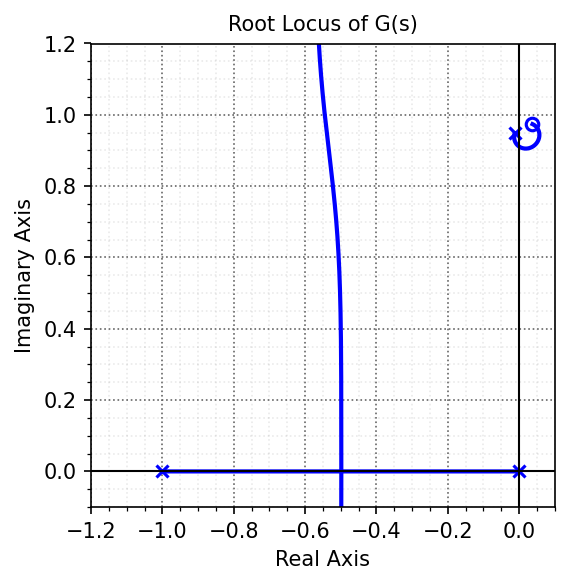

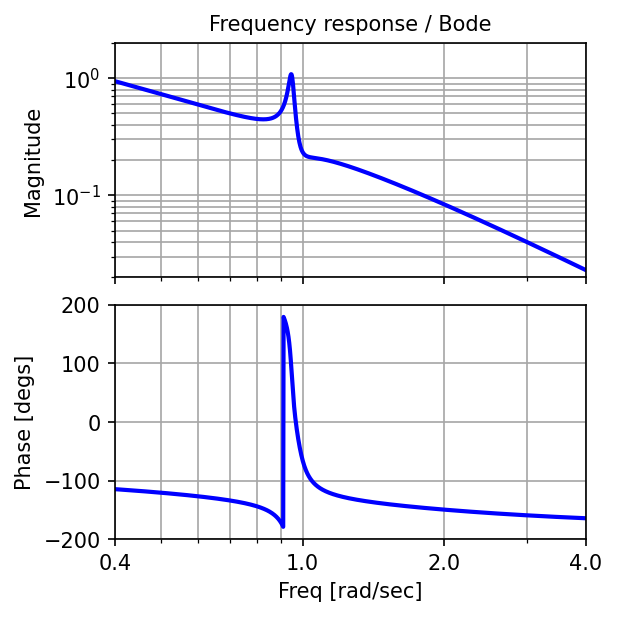

In [30]:
w = np.hstack(([0.0], np.logspace(-3,1,5000)))
G = 0.38*ct.tf([1],[1, 1, 0])*ct.tf([1,-.075,.95],[1,.025,.9]) 
display(cm.show_tf_latex(G,'G(s)'))

[Gm,Gp,Gw] = ct.frequency_response(G,omega=w)

fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
plt.sca(ax);
kwargs = {'color':'g'}
cm.nyquist(G,w,indent_direction='right',indent_points=100,**kwargs)
plt.plot(np.cos(an), np.sin(an),'b-',lw=1)
plt.plot(-1,0,'rx',ms=6)
ax.set_aspect('equal')
plt.xlim([-1.25,1.25])
plt.ylim([-1.25,1.25])
bm.nicegrid(ax,-1)
plt.title('Nyquist Plot of G(s)')

gm, pm, wcg, wcp =  ct.margin(G)
plt.plot([0,-np.cos(pm/cm.r2d)],[0,-np.sin(pm/cm.r2d)],'r--')
Gf = G(complex(0,1)*w)
S = 1/(1+Gf)
dist_from_cp = 1/np.max(np.abs(S))
plt.plot(-1+dist_from_cp*np.cos(an), dist_from_cp*np.sin(an),'r--',lw=1)

ax.text(.5,-1.1,"PM = {:3.2f}".format(pm),backgroundcolor = 'w', color = 'k', fontsize=10)
ax.text(-1.1,-1.1,"GM = {:3.2f}".format(gm),backgroundcolor = 'w', color = 'k', fontsize=10)

plt.savefig("./figs/L19_GM_PM_2.pdf", dpi=600)
plt.show()

print("Phase Margin = {:3.2f}".format(pm))
plt.rcParams.update({'figure.autolayout': True})

fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
rl = ct.rlocus(G, gains=cm.Root_Locus_gains(G), color='b',ax=ax)
bm.nicegrid(ax)
ax.set_xlim([-1.2,.1])
ax.set_ylim([-0.1,1.2])
ax.set_aspect('equal')
ax.set_xlabel('Real Axis')
ax.set_ylabel('Imaginary Axis') 
plt.title('Root Locus of G(s)')
plt.savefig("./figs/L19_GM_PM_2a.pdf", dpi=600)

fig, ax = plt.subplots(2,1,figsize=(4, 4),dpi=150, sharex = True,constrained_layout = True)
ax[0].loglog(Gw,Gm,'b')
ax[1].semilogx(Gw,cm.pshift(Gp)*cm.r2d,'b')
ax[0].set_xlim([.4,4])
ax[0].set_ylim([.02,2])
ax[1].set_ylim([-200,200])
ax[0].grid(True, which="both", ls="-",color='0.65')
ax[1].grid(True, which="both", ls="-",color='0.65')
ax[1].set_xlabel('Freq [rad/sec]')
ax[1].set_ylabel('Phase [degs]')
ax[0].set_ylabel('Magnitude')
ax[0].set_title("Frequency response / Bode")

ax[0].set_xscale('log')
ax[0].xaxis.set_major_locator(LogLocator(base=10, subs=(1.0, 2.0, 4.0)))
ax[0].xaxis.set_major_formatter(ScalarFormatter())
ax[0].xaxis.set_minor_formatter(plt.NullFormatter())
plt.savefig("./figs/L19_GM_PM_2b.pdf", dpi=600)


<IPython.core.display.Math object>

None

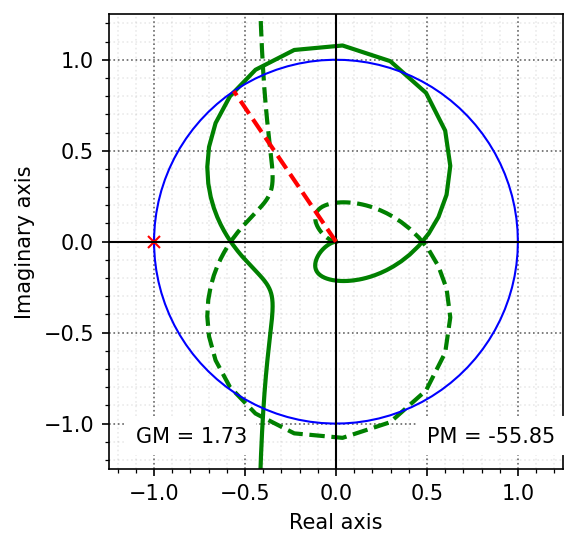

In [31]:
w = np.hstack(([0.0], np.logspace(-3,3,5000)))
G = 0.38*ct.tf([1],[1, 1, 0])*ct.tf([1,-.075,.95],[1,.025,.9]) 
display(cm.show_tf_latex(G,'G(s)'))

[Gm,Gp,Gw] = ct.frequency_response(G,omega=w)

fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
plt.sca(ax);
kwargs = {'color':'g'}
cm.nyquist(G,w,indent_direction='right',indent_points=100,**kwargs)
#lines = ax.get_lines()
#[lines[x].set_linestyle('-') for x in range(int(len(lines)))]
plt.plot(np.cos(an), np.sin(an),'b-',lw=1)
plt.plot(-1,0,'rx',ms=6)
ax.set_aspect('equal')
plt.xlim([-1.25,1.25])
plt.ylim([-1.25,1.25])
bm.nicegrid(ax,-1)

gm, pm, wcg, wcp =  ct.margin(G)
plt.plot([0,-np.cos(pm/cm.r2d)],[0,-np.sin(pm/cm.r2d)],'r--')
Gf = G(complex(0,1)*w)
S = 1/(1+Gf)
dist_from_cp = 1/np.max(np.abs(S))
plt.plot(-1+dist_from_cp*np.cos(an), dist_from_cp*np.sin(an),'r--',lw=1)

ax.text(.5,-1.1,"PM = {:3.2f}".format(pm),backgroundcolor = 'w', color = 'k', fontsize=10)
ax.text(-1.1,-1.1,"GM = {:3.2f}".format(gm),backgroundcolor = 'w', color = 'k', fontsize=10)
plt.savefig("./figs/L19_Rob_2.pdf", dpi=600)
plt.show()

## Stability analysis example on 17-12


Found break-in/out at K =  3.732
At possible locations s = -1.366

Found break-in/out at K =  0.268
At possible locations s =  0.366


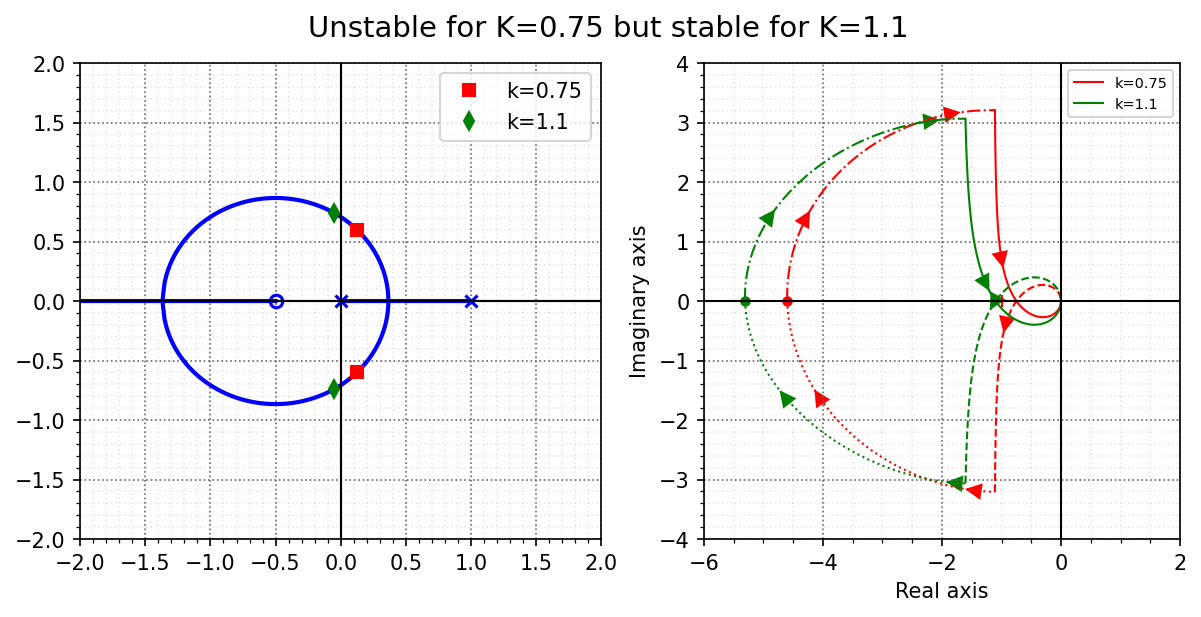

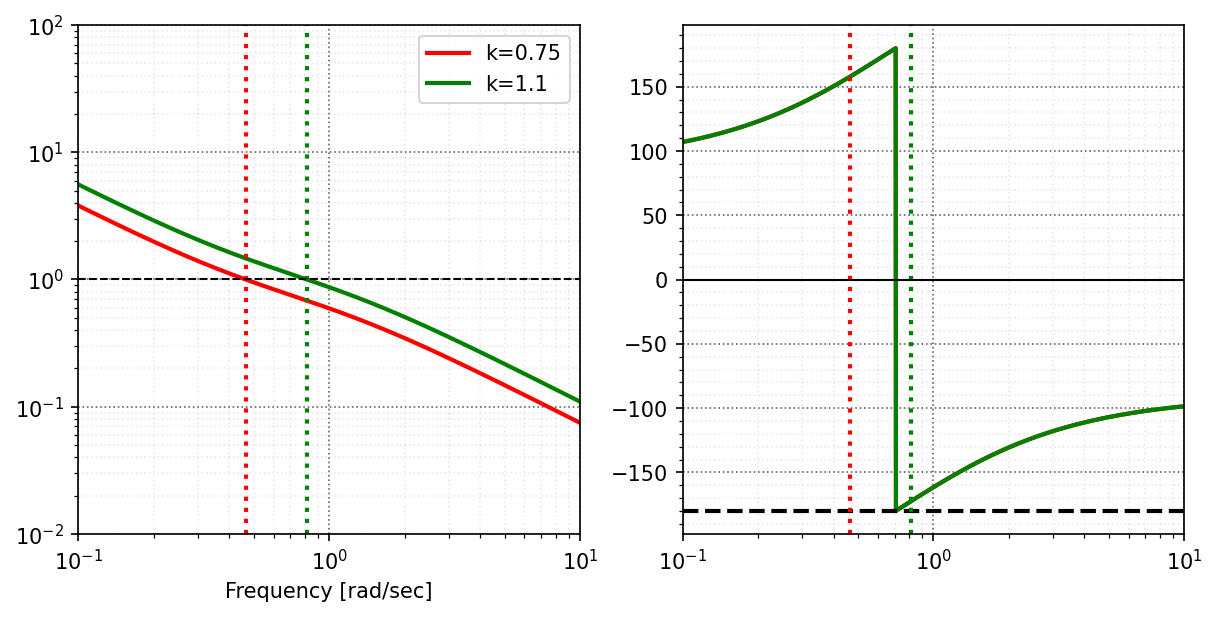

In [32]:
gain1 = 0.75
gain2 = 1.1
G = 0.5*ct.tf((2,1),(1,-1,0))
Gcl1 = ct.feedback(G,gain1)
Gcl3 = ct.feedback(G,gain2)
scl1 = Gcl1.poles()
scl3 = Gcl3.poles()

fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150,constrained_layout = True)
rl = ct.rlocus(G, gains=cm.Root_Locus_gains(G), color='b', ax=ax[0])
ax[0].set_xlim([-2, 2]);ax[0].set_ylim([-2, 2])
bm.nicegrid(ax[0])
#ax[0].set_title('Gamma > 0, K={:2d}'.format(K),loc='left')
ax[0].plot(scl1.real,scl1.imag,'rs',ms=6,label='k='+str(gain1))
ax[0].plot(scl3.real,scl3.imag,'gd',ms=6,label='k='+str(gain2))
h, l = ax[0].get_legend_handles_labels()
ax[0].legend(handles=[item for item in h[2:]], labels= [item for item in l[2:]])
                                                    
RR = .15
plt.sca(ax[1])
kwargs = {'color':'r','linewidth':1}
cm.nyquist(gain1*G,w,indent_direction='right',indent_radius=gain1*RR,indent_points=200,ax=ax[1],label='k='+str(gain1),**kwargs)
kwargs = {'color':'g','linewidth':1}
cm.nyquist(gain2*G,w,indent_direction='right',indent_radius=RR*gain2,indent_points=200,ax=ax[1],label='k='+str(gain2),**kwargs)
plt.xlim([-6,2])
plt.ylim([-4,4])
ax[1].set_aspect('equal')
bm.nicegrid(ax)
plt.suptitle("Unstable for K="+str(gain1)+" but stable for K="+str(gain2),fontsize=14)
plt.savefig('./figs/L15_10.pdf')
plt.show()

fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150,constrained_layout = True)
j = complex(0,1)
Gfreq1 = G(j*w)

ax[0].loglog(w,gain1*np.abs(Gfreq1),'r')
ax[1].semilogx(w,cm.pshift(np.angle(Gfreq1))*cm.r2d,'r')
ax[0].loglog(w,gain2*np.abs(Gfreq1),'g')
ax[1].semilogx(w,cm.pshift(np.angle(Gfreq1))*cm.r2d,'g')

ax1,ax2 = plt.gcf().axes
ax1.legend(('k='+str(gain1),'k='+str(gain2)))
ax2.axhline(y=-180,c='k',ls="--")
wc1 = cm.find_wc(w,gain1*G)
wc3 = cm.find_wc(w,gain2*G)
for wwc in wc1[::2]:
    ax1.axvline(x=wwc,c='r',ls=":")
    ax2.axvline(x=wwc,c='r',ls=":")
for wwc in wc3[::2]:
    ax1.axvline(x=wwc,c='g',ls=":")
    ax2.axvline(x=wwc,c='g',ls=":")
ax[0].set_xlim([.1,10])
ax[1].set_xlim([.1,10])
ax[0].set_ylim([.01,100])
ax[0].set_xlabel("Frequency [rad/sec]")
bm.nicegrid(ax)
plt.savefig('./figs/L15_11.pdf')
plt.show()